# Day 51 — Time Series Forecasting
### Trend & Seasonality · ARIMA · Prophet · Forecasting Evaluation

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# install prophet if needed
try:
    from prophet import Prophet
    print("Prophet installed ✅")
except:
    import subprocess
    subprocess.run(['pip', 'install', 'prophet', '--quiet'])
    from prophet import Prophet
    print("Prophet installed ✅")

plt.style.use('dark_background')
print("All imports ready! ✅")
print("Topic: Time Series Forecasting — predicting the future from the past")

Prophet installed ✅
All imports ready! ✅
Topic: Time Series Forecasting — predicting the future from the past


## 2. What is Time Series Forecasting?

In [2]:
print("=" * 55)
print("       WHAT IS TIME SERIES FORECASTING?")
print("=" * 55)
print("""
TIME SERIES = data points indexed in time order
  Examples: stock prices, sales, temperature, website traffic

WHY IT'S DIFFERENT FROM REGULAR ML:
  Order matters — can't shuffle the data!
  Observations are correlated with their neighbours
  Train/test split must respect time (no random shuffling)

KEY COMPONENTS OF A TIME SERIES:

  1. TREND
     Long-term increase or decrease
     e.g. company revenue growing year over year

  2. SEASONALITY
     Repeating pattern at fixed intervals
     e.g. ice cream sales peak every summer

  3. CYCLICAL
     Longer, irregular fluctuations
     e.g. economic boom/recession cycles

  4. NOISE / RESIDUAL
     Random variation left after removing trend & seasonality

STATIONARITY — CRITICAL CONCEPT:
  A series is STATIONARY if its statistical properties
  (mean, variance) don't change over time
  Most classical models (ARIMA) REQUIRE stationarity
  Test with: Augmented Dickey-Fuller (ADF) test

FORECASTING APPROACHES:
  Classical:  ARIMA, SARIMA, Exponential Smoothing
  Modern:     Prophet (Facebook/Meta), automatic seasonality
  ML-based:   XGBoost with lag features, LSTM (Day 40!)
""")

       WHAT IS TIME SERIES FORECASTING?

TIME SERIES = data points indexed in time order
  Examples: stock prices, sales, temperature, website traffic

WHY IT'S DIFFERENT FROM REGULAR ML:
  Order matters — can't shuffle the data!
  Observations are correlated with their neighbours
  Train/test split must respect time (no random shuffling)

KEY COMPONENTS OF A TIME SERIES:

  1. TREND
     Long-term increase or decrease
     e.g. company revenue growing year over year

  2. SEASONALITY
     Repeating pattern at fixed intervals
     e.g. ice cream sales peak every summer

  3. CYCLICAL
     Longer, irregular fluctuations
     e.g. economic boom/recession cycles

  4. NOISE / RESIDUAL
     Random variation left after removing trend & seasonality

STATIONARITY — CRITICAL CONCEPT:
  A series is STATIONARY if its statistical properties
  (mean, variance) don't change over time
  Most classical models (ARIMA) REQUIRE stationarity
  Test with: Augmented Dickey-Fuller (ADF) test

FORECASTING AP

## 3. Generate & Decompose a Time Series

       GENERATE & DECOMPOSE TIME SERIES
Time series length: 1095 days
Date range: 2023-01-01 to 2025-12-30

First 5 rows:
                 sales
date                  
2023-01-01  103.973713
2023-01-02  107.193343
2023-01-03  115.892972
2023-01-04  117.966098
2023-01-05   95.711490


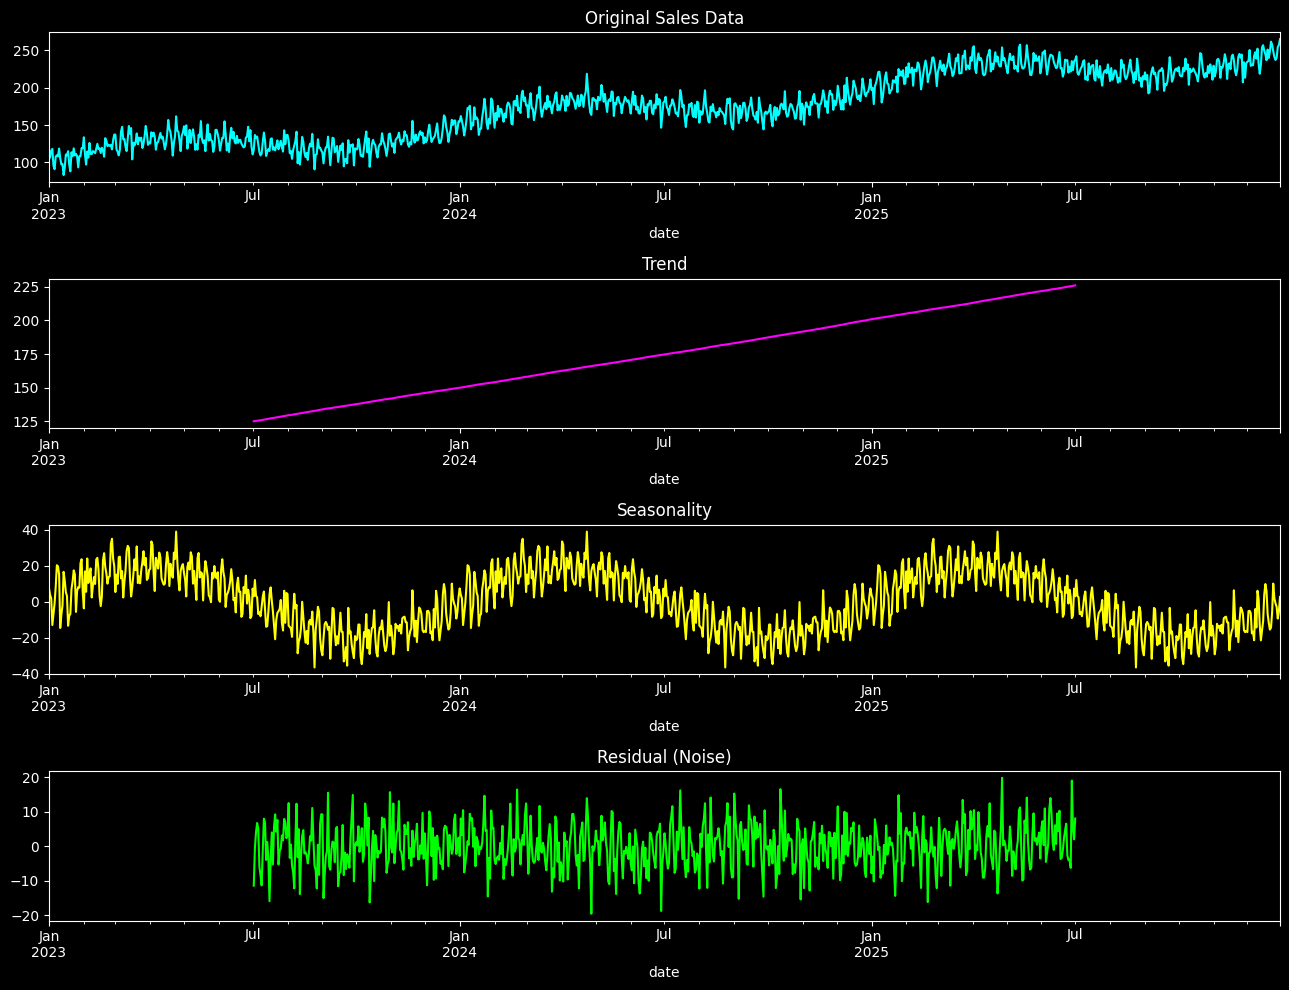

In [3]:
print("=" * 55)
print("       GENERATE & DECOMPOSE TIME SERIES")
print("=" * 55)

# simulate 3 years of daily sales data with trend + weekly seasonality + noise
np.random.seed(42)
n_days = 365 * 3
dates  = pd.date_range(start='2023-01-01', periods=n_days, freq='D')

trend      = np.linspace(100, 250, n_days)                          # upward trend
seasonality = 20 * np.sin(2 * np.pi * np.arange(n_days) / 365.25)   # yearly cycle
weekly      = 10 * np.sin(2 * np.pi * np.arange(n_days) / 7)        # weekly cycle
noise       = np.random.normal(0, 8, n_days)

sales = trend + seasonality + weekly + noise
sales = np.maximum(sales, 0)  # no negative sales

df = pd.DataFrame({'date': dates, 'sales': sales})
df.set_index('date', inplace=True)

print(f"Time series length: {len(df)} days")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"\nFirst 5 rows:")
print(df.head())

# decompose into trend, seasonal, residual
decomposition = seasonal_decompose(df['sales'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(13, 10))
df['sales'].plot(ax=axes[0], color='cyan', title='Original Sales Data')
decomposition.trend.plot(ax=axes[1], color='magenta', title='Trend')
decomposition.seasonal.plot(ax=axes[2], color='yellow', title='Seasonality')
decomposition.resid.plot(ax=axes[3], color='lime', title='Residual (Noise)')
plt.tight_layout()
plt.show()

## 4. Stationarity Test (ADF Test)

       STATIONARITY TEST

AUGMENTED DICKEY-FULLER (ADF) TEST:
  Null hypothesis (H0): series is NON-stationary
  Alternative (H1):     series IS stationary

  p-value < 0.05 → reject H0 → series IS stationary
  p-value > 0.05 → series is NOT stationary → need differencing

Original Sales (with trend):
  ADF Statistic: -0.4180
  p-value:       0.9070
  Stationary?    NO ❌ — needs differencing

Differenced Sales (1st difference):
  ADF Statistic: -7.3960
  p-value:       0.0000
  Stationary?    YES ✅



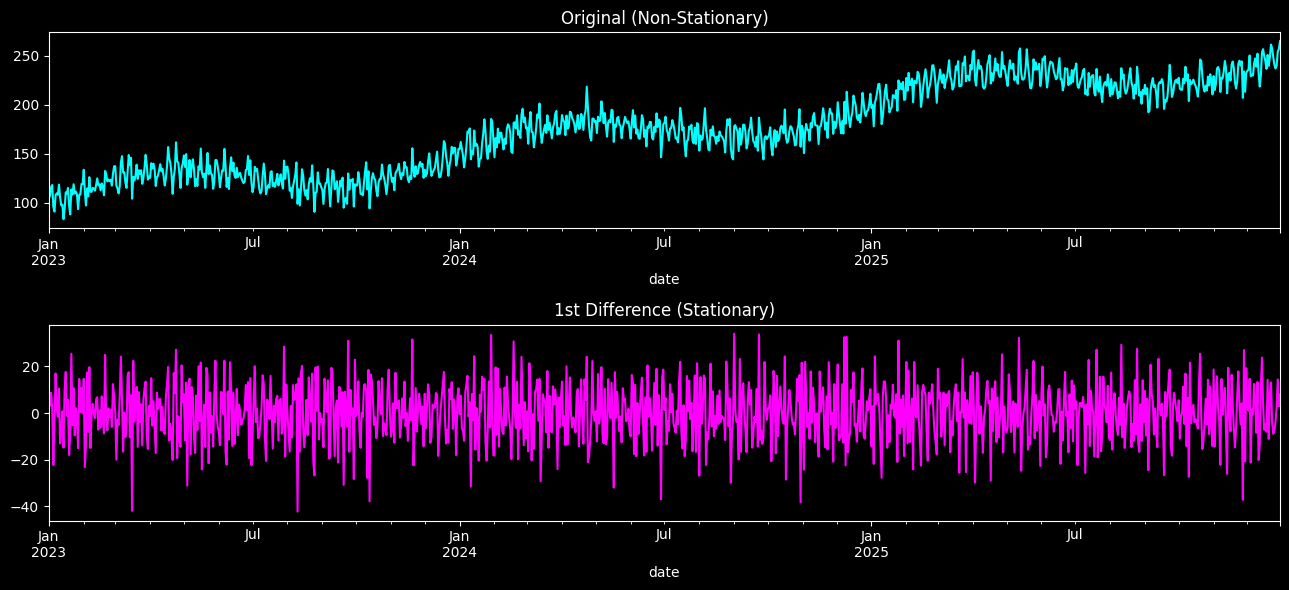

In [4]:
print("=" * 55)
print("       STATIONARITY TEST")
print("=" * 55)
print("""
AUGMENTED DICKEY-FULLER (ADF) TEST:
  Null hypothesis (H0): series is NON-stationary
  Alternative (H1):     series IS stationary

  p-value < 0.05 → reject H0 → series IS stationary
  p-value > 0.05 → series is NOT stationary → need differencing
""")

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"{name}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value:       {result[1]:.4f}")
    print(f"  Stationary?    {'YES ✅' if result[1] < 0.05 else 'NO ❌ — needs differencing'}")
    print()

# test original series (has trend → should be non-stationary)
adf_test(df['sales'], "Original Sales (with trend)")

# difference the series — removes trend
df['sales_diff'] = df['sales'].diff()
adf_test(df['sales_diff'], "Differenced Sales (1st difference)")

# plot both
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
df['sales'].plot(ax=axes[0], color='cyan', title='Original (Non-Stationary)')
df['sales_diff'].plot(ax=axes[1], color='magenta', title='1st Difference (Stationary)')
plt.tight_layout()
plt.show()

## 5. ARIMA Forecasting

       ARIMA FORECASTING

ARIMA(p, d, q):
  p = AR (AutoRegressive) order — how many past values to use
  d = Differencing order — how many times to difference for stationarity
  q = MA (Moving Average) order — how many past errors to use

  We found d=1 from the ADF test above.

Train size: 1005 days
Test size:  90 days (last 90 days)


c:\DS-AI-75d\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\DS-AI-75d\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\DS-AI-75d\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



ARIMA(2,1,2) AIC: 7444.69
ARIMA MAE:  13.36
ARIMA RMSE: 16.75


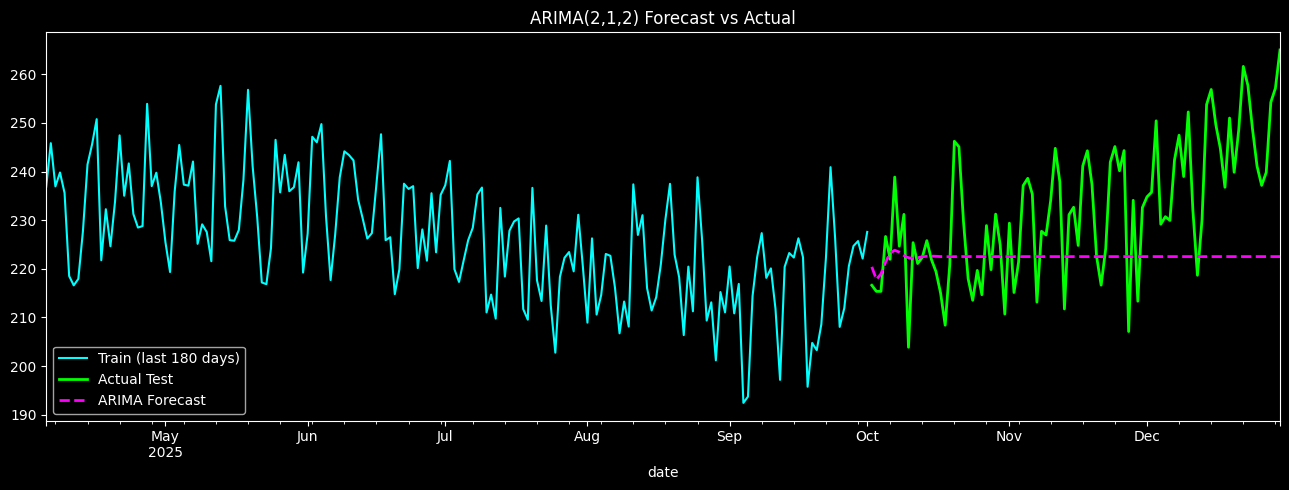

In [5]:
print("=" * 55)
print("       ARIMA FORECASTING")
print("=" * 55)
print("""
ARIMA(p, d, q):
  p = AR (AutoRegressive) order — how many past values to use
  d = Differencing order — how many times to difference for stationarity
  q = MA (Moving Average) order — how many past errors to use

  We found d=1 from the ADF test above.
""")

# train/test split — respect time order!
train_size = len(df) - 90  # last 90 days as test
train, test = df['sales'][:train_size], df['sales'][train_size:]

print(f"Train size: {len(train)} days")
print(f"Test size:  {len(test)} days (last 90 days)")

# fit ARIMA(2,1,2)
model_arima = ARIMA(train, order=(2,1,2))
fitted_arima = model_arima.fit()
print(f"\nARIMA(2,1,2) AIC: {fitted_arima.aic:.2f}")

# forecast
forecast_arima = fitted_arima.forecast(steps=len(test))

# evaluate
mae_arima  = mean_absolute_error(test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
print(f"ARIMA MAE:  {mae_arima:.2f}")
print(f"ARIMA RMSE: {rmse_arima:.2f}")

# plot
fig, ax = plt.subplots(figsize=(13, 5))
train[-180:].plot(ax=ax, color='cyan', label='Train (last 180 days)')
test.plot(ax=ax, color='lime', label='Actual Test', linewidth=2)
forecast_arima.plot(ax=ax, color='magenta', label='ARIMA Forecast',
                    linewidth=2, linestyle='--')
ax.set_title('ARIMA(2,1,2) Forecast vs Actual')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Prophet Forecasting

       PROPHET FORECASTING

PROPHET (by Facebook/Meta):
  Designed for business time series with strong seasonality
  Automatically detects yearly, weekly, daily patterns
  Robust to missing data and outliers
  Much easier to use than manually tuning ARIMA orders



18:40:21 - cmdstanpy - INFO - Chain [1] start processing
18:40:22 - cmdstanpy - INFO - Chain [1] done processing



Prophet MAE:  5.95
Prophet RMSE: 7.52

COMPARISON:
Model             MAE     RMSE
------------------------------
ARIMA           13.36    16.75
Prophet          5.95     7.52


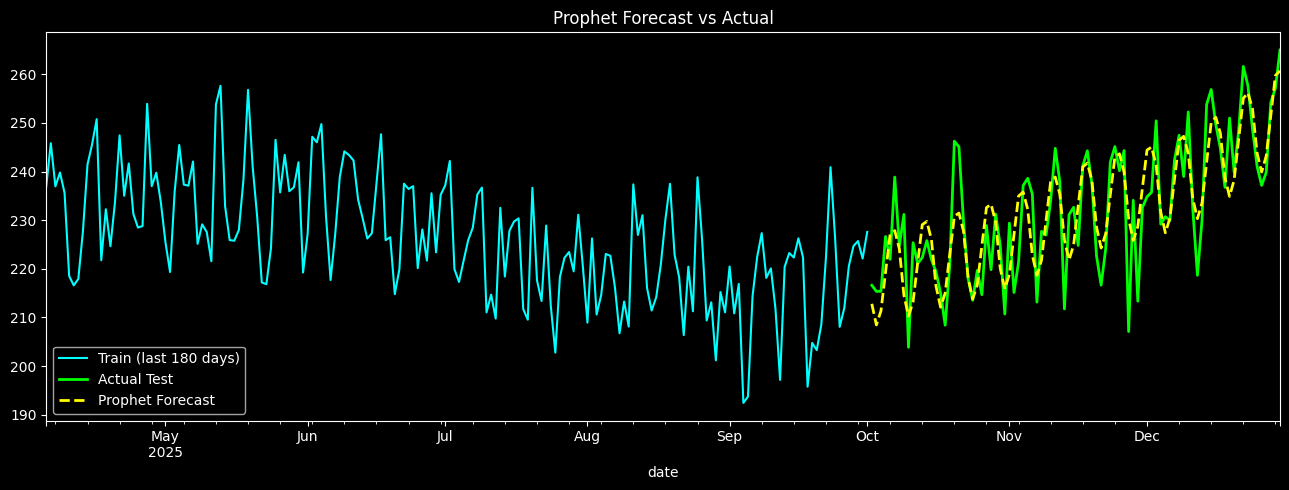

In [6]:
print("=" * 55)
print("       PROPHET FORECASTING")
print("=" * 55)
print("""
PROPHET (by Facebook/Meta):
  Designed for business time series with strong seasonality
  Automatically detects yearly, weekly, daily patterns
  Robust to missing data and outliers
  Much easier to use than manually tuning ARIMA orders
""")

# prophet needs columns named 'ds' (date) and 'y' (value)
prophet_df = train.reset_index()
prophet_df.columns = ['ds', 'y']

model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                        daily_seasonality=False)
model_prophet.fit(prophet_df)

# create future dataframe for the test period
future = model_prophet.make_future_dataframe(periods=len(test))
forecast_prophet = model_prophet.predict(future)

# extract just the test period predictions
forecast_test = forecast_prophet.iloc[-len(test):]['yhat'].values

# evaluate
mae_prophet  = mean_absolute_error(test, forecast_test)
rmse_prophet = np.sqrt(mean_squared_error(test, forecast_test))

print(f"\nProphet MAE:  {mae_prophet:.2f}")
print(f"Prophet RMSE: {rmse_prophet:.2f}")

print(f"\nCOMPARISON:")
print(f"{'Model':<12} {'MAE':>8} {'RMSE':>8}")
print("-" * 30)
print(f"{'ARIMA':<12} {mae_arima:>8.2f} {rmse_arima:>8.2f}")
print(f"{'Prophet':<12} {mae_prophet:>8.2f} {rmse_prophet:>8.2f}")

# plot
fig, ax = plt.subplots(figsize=(13, 5))
train[-180:].plot(ax=ax, color='cyan', label='Train (last 180 days)')
test.plot(ax=ax, color='lime', label='Actual Test', linewidth=2)
ax.plot(test.index, forecast_test, color='yellow', linewidth=2,
       linestyle='--', label='Prophet Forecast')
ax.set_title('Prophet Forecast vs Actual')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Key Takeaways

In [7]:
print("=" * 55)
print("       DAY 51 — KEY TAKEAWAYS")
print("=" * 55)
print("""
TIME SERIES FUNDAMENTALS:
  ✅ Order matters — never shuffle time series data
  ✅ Components: Trend + Seasonality + Cyclical + Noise
  ✅ seasonal_decompose() splits series into these parts

STATIONARITY:
  ✅ ADF test — p<0.05 means stationary
  ✅ Our original series: p=0.907 — NOT stationary (trend)
  ✅ After differencing: p=0.0000 — stationary ✅
  ✅ ARIMA requires stationary data (the 'd' parameter)

ARIMA:
  ✅ ARIMA(p,d,q) — AutoRegressive Integrated Moving Average
  ✅ p=AR order, d=differencing, q=MA order
  ✅ MAE: 13.36, RMSE: 16.75
  ✅ Weakness: forecast flattens — no seasonal awareness!

PROPHET:
  ✅ Built by Meta for business forecasting
  ✅ Automatically detects yearly/weekly/daily seasonality
  ✅ MAE: 5.95, RMSE: 7.52 — over 2x better than ARIMA!
  ✅ Tracked weekly oscillations ARIMA completely missed

KEY LESSON:
  ✅ Model choice depends on the DATA's characteristics
  ✅ Strong seasonality → Prophet (or SARIMA) wins
  ✅ Plain ARIMA struggles without seasonal terms
  ✅ Always visualize forecasts — metrics alone can mislead

WHEN TO USE WHAT:
  ✅ ARIMA/SARIMA → strong statistical foundation, interpretable
  ✅ Prophet       → business data, easy seasonality handling
  ✅ LSTM (Day 40) → complex non-linear patterns, lots of data
  ✅ XGBoost+lags  → tabular ML approach, feature-rich data
""")

       DAY 51 — KEY TAKEAWAYS

TIME SERIES FUNDAMENTALS:
  ✅ Order matters — never shuffle time series data
  ✅ Components: Trend + Seasonality + Cyclical + Noise
  ✅ seasonal_decompose() splits series into these parts

STATIONARITY:
  ✅ ADF test — p<0.05 means stationary
  ✅ Our original series: p=0.907 — NOT stationary (trend)
  ✅ After differencing: p=0.0000 — stationary ✅
  ✅ ARIMA requires stationary data (the 'd' parameter)

ARIMA:
  ✅ ARIMA(p,d,q) — AutoRegressive Integrated Moving Average
  ✅ p=AR order, d=differencing, q=MA order
  ✅ MAE: 13.36, RMSE: 16.75
  ✅ Weakness: forecast flattens — no seasonal awareness!

PROPHET:
  ✅ Built by Meta for business forecasting
  ✅ Automatically detects yearly/weekly/daily seasonality
  ✅ MAE: 5.95, RMSE: 7.52 — over 2x better than ARIMA!
  ✅ Tracked weekly oscillations ARIMA completely missed

KEY LESSON:
  ✅ Model choice depends on the DATA's characteristics
  ✅ Strong seasonality → Prophet (or SARIMA) wins
  ✅ Plain ARIMA struggles with